In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


C:\Users\SANKET\miniconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.0)
  from scipy.stats import gaussian_kde


AttributeError: module 'numpy.random.bit_generator' has no attribute 'SeedlessSequence'

In [2]:
!pip install pandas numpy seaborn


In [3]:
!pip install matplotlib


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

AttributeError: module 'numpy.random.bit_generator' has no attribute 'SeedlessSequence'

In [5]:
!pip install --upgrade numpy scipy seaborn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
    --------------------------------------- 0.2/12.3 MB 4.9 MB/s eta 0:00:03
   - -------------------------------------- 0.5/12.3 MB 5.7 MB/s eta 0:00:03
   -- ------------------------------------- 0.8/12.3 MB 5.9 MB/s eta 0:00:02
   --- ------------------------------------ 1.2/12.3 MB 6.7 MB/s eta 0:00:02
   ---- ----------------------------------- 1.5/12.3 MB 6.4 MB/s eta 0:00:02
   ----- ---------------------------------- 1.8/12.3 MB 6.8 MB/s eta 0:00:02
   ------ --------------------------------- 2.1/12.3 MB 6.4 MB/s eta 0:00:02
   ------- -------------------------------- 2.4/12.3 MB 6.7 MB/s eta 0:00:02
   -------- ------------------------------- 2.7/12.3 MB 6.5 MB/s eta 0:00:02
   --------- ------------------------------ 3.0/12.3 MB 6.6 MB/s eta 0:00:02
   -----

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.4.6 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [7]:
fear_df = pd.read_csv("fear_greed_index.csv")
trade_df = pd.read_csv("historical_data.csv")

print("Fear Dataset Shape:", fear_df.shape)
print("Trade Dataset Shape:", trade_df.shape)

fear_df.head()

Fear Dataset Shape: (2644, 4)
Trade Dataset Shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
trade_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [9]:
fear_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
print(fear_df['date'].head())

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [11]:
print(trade_df['Timestamp IST'].head())

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object


In [12]:
trade_df.columns
trade_df.info()
trade_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [13]:
fear_df['date'] = pd.to_datetime(fear_df['date'])

In [14]:
trade_df['Timestamp IST'] = pd.to_datetime(
    trade_df['Timestamp IST'],
    dayfirst=True
)

In [15]:
trade_df['date'] = trade_df['Timestamp IST'].dt.date
trade_df['date'] = pd.to_datetime(trade_df['date'])

In [16]:
print("Fear Range:")
print(fear_df['date'].min())
print(fear_df['date'].max())

print()

print("Trade Range:")
print(trade_df['date'].min())
print(trade_df['date'].max())

Fear Range:
2018-02-01 00:00:00
2025-05-02 00:00:00

Trade Range:
2023-05-01 00:00:00
2025-05-01 00:00:00


In [17]:
fear_df['classification'].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [18]:
merged_df = pd.merge(
    trade_df,
    fear_df[['date', 'classification', 'value']],
    on='date',
    how='inner'
)

print("Merged Shape:", merged_df.shape)
merged_df.head()

Merged Shape: (211218, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80


In [19]:
merged_df['Win'] = (merged_df['Closed PnL'] > 0).astype(int)

In [20]:
merged_df[['Closed PnL', 'Win']].head()

,Closed PnL,Win
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


In [21]:
fear_df['classification'].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [22]:
merged_df.groupby('classification')['Closed PnL'].agg(
    ['count', 'mean', 'median', 'sum']
).sort_values('mean', ascending=False)

,count,mean,median,sum
classification,,,,
Extreme Greed,39992,67.892861,0.0,2.715171e+06
Fear,61837,54.290400,0.0,3.357155e+06
Greed,50303,42.743559,0.0,2.150129e+06
Extreme Fear,21400,34.537862,0.0,7.391102e+05
Neutral,37686,34.307718,0.0,1.292921e+06


In [23]:
win_rate = merged_df.groupby('classification')['Win'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


In [24]:
pnl_analysis = merged_df.groupby('classification')['Closed PnL'].agg(
    ['count', 'mean', 'median', 'sum']
).sort_values('mean', ascending=False)

print(pnl_analysis)

                count       mean  median           sum
classification                                        
Extreme Greed   39992  67.892861     0.0  2.715171e+06
Fear            61837  54.290400     0.0  3.357155e+06
Greed           50303  42.743559     0.0  2.150129e+06
Extreme Fear    21400  34.537862     0.0  7.391102e+05
Neutral         37686  34.307718     0.0  1.292921e+06


In [25]:
trade_count = merged_df['classification'].value_counts()

print(trade_count)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [26]:
size_analysis = merged_df.groupby('classification')['Size USD'].agg(
    ['count', 'mean', 'median', 'max']
).sort_values('mean', ascending=False)

print(size_analysis)

                count         mean   median         max
classification                                         
Fear            61837  7816.109931  735.960  3921430.72
Greed           50303  5736.884375  555.000  2227114.71
Extreme Fear    21400  5349.731843  766.150  1120971.60
Neutral         37686  4782.732661  547.655  3641180.84
Extreme Greed   39992  3112.251565  500.050   665771.71


In [27]:
fee_analysis = merged_df.groupby('classification')['Fee'].agg(
    ['mean', 'sum']
)

print(fee_analysis)

                    mean           sum
classification                        
Extreme Fear    1.116291  23888.633939
Extreme Greed   0.675902  27030.665465
Fear            1.495172  92456.948674
Greed           1.254372  63098.691979
Neutral         1.044798  39374.268304


In [28]:
top_traders = merged_df.groupby('Account').agg({
    'Closed PnL':'sum',
    'Win':'mean',
    'Size USD':'mean'
})

top_traders = top_traders.sort_values(
    'Closed PnL',
    ascending=False
)

print(top_traders.head(10))

                                              Closed PnL       Win  \
Account                                                              
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06  0.337134   
0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  0.359612   
0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05  0.467582   
0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05  0.401193   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05  0.428230   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  6.777471e+05  0.486226   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.293556e+05  0.345912   
0x430f09841d65beb3f27765503d0f850b8bce7713  4.165419e+05  0.484236   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  3.790954e+05  0.810876   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0  3.605395e+05  0.303371   

                                                Size USD  
Account                                                   
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed2

In [29]:
trader_summary = merged_df.groupby('Account').agg({
    'Closed PnL':'sum',
    'Win':'mean',
    'Size USD':'mean',
    'Fee':'mean'
}).reset_index()

trader_summary = trader_summary.sort_values(
    'Closed PnL',
    ascending=False
)

print(trader_summary.head())
print(trader_summary.tail())

                                       Account    Closed PnL       Win  \
27  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06  0.337134   
0   0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  0.359612   
29  0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05  0.467582   
13  0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05  0.401193   
31  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05  0.428230   

        Size USD       Fee  
27   3837.885375  1.085680  
0   16159.576734  1.939579  
29   3210.472831  0.405658  
13  34396.580284  6.245885  
31   1844.211886  0.332294  
                                       Account     Closed PnL       Win  \
18  0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f   14900.443047  0.452213   
6   0x39cef799f8b69da1995852eea189df24eb5cae3c   14456.919336  0.327668   
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  -31203.599986  0.455215   
2   0x271b280974205ca63b716753467d5a371de622ab  -70436.191318  0.301917   
19  0x

In [30]:
merged_df.groupby(
    ['classification', 'Coin']
)['Closed PnL'].mean().unstack()

Coin,@1,@10,@100,@103,@107,@109,@11,@112,@113,@114,@116,@117,@12,@123,@124,@125,@13,@135,@138,@14,@142,@147,@15,@151,@152,@153,@16,@17,@18,@19,@2,@20,@21,@23,@24,@25,@26,@28,@29,@3,@30,@31,@32,@33,@34,@35,@36,@37,@38,@39,@4,@40,@41,@42,@44,@45,@46,@47,@48,@49,@51,@53,@59,@6,@61,@63,@68,@7,@74,@78,@8,@83,@85,@86,@9,@93,@95,AAVE,ACE,ADA,AI,AI16Z,AIXBT,ALGO,ALT,ANIME,APE,APT,AR,ARB,ARK,ATOM,AVAX,BABY,BADGER,BANANA,BERA,BIGTIME,BIO,BLAST,BLUR,BNB,BNT,BOME,BRETT,BTC,CAKE,CANTO,CHILLGUY,COMP,CRV,CYBER,DOGE,DOT,DYDX,DYM,EIGEN,ENA,ENS,ETC,ETH,ETHFI,FARTCOIN,FET,FIL,FTM,FTT,FXS,GALA,GAS,GMT,GMX,GOAT,GRASS,GRIFFAIN,HBAR,HPOS,HYPE,HYPER,ILV,IMX,INIT,INJ,IO,IOTA,IP,JELLY,JTO,JUP,KAITO,LAYER,LDO,LINK,LISTA,LOOM,LTC,MANTA,MATIC,MAV,MAVIA,ME,MELANIA,MEME,MERL,MEW,MINA,MKR,MNT,MOODENG,MORPHO,MOVE,MYRO,NEAR,NEIROETH,NIL,NTRN,OGN,OM,ONDO,OP,ORDI,PAXG,PENDLE,PENGU,PEOPLE,PIXEL,PNUT,POLYX,POPCAT,PROMPT,PURR,PURR/USDC,PYTH,RENDER,REQ,REZ,RLB,RNDR,RSR,RUNE,S,SAND,SCR,SEI,SHIA,SOL,SPX,STG,STRK,STX,SUI,SUPER,SUSHI,TAO,TIA,TNSR,TON,TRUMP,TRX,TST,TURBO,UNI,UNIBOT,USTC,USUAL,VINE,VIRTUAL,VVV,W,WCT,WIF,WLD,XAI,XRP,YGG,ZEN,ZEREBRO,ZETA,ZK,ZORA,ZRO,kBONK,kFLOKI,kNEIRO,kPEPE,kSHIB
classification,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Extreme Fear,NaN,-0.031742,NaN,NaN,-89.588788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.061895,NaN,NaN,NaN,15.529335,NaN,NaN,NaN,NaN,NaN,-0.030214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.032252,NaN,-0.019593,NaN,NaN,NaN,NaN,NaN,NaN,33.514063,NaN,NaN,33.271993,12.238556,-13.810710,16.748319,36.73844,NaN,NaN,NaN,NaN,25.156729,NaN,-10.178054,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.432312,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,-182.081319,0.000000,99.000812,0.000000,NaN,NaN,4.225193,0.776420,0.000000,NaN,14.826568,NaN,NaN,10.324872,NaN,NaN,NaN,64.313320,NaN,NaN,NaN,NaN,22.878156,NaN,NaN,NaN,1.731921,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,120.348892,NaN,NaN,196.927660,NaN,-244.272754,NaN,NaN,NaN,37.156913,NaN,NaN,NaN,1.544824,47.877753,14.905763,15.242015,-94.523107,NaN,NaN,46.904438,NaN,NaN,NaN,NaN,NaN,0.036820,NaN,25.961200,38.782874,4.817301,1.939093,49.261651,NaN,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,218.338940,NaN,NaN,NaN,NaN,3.685672,NaN,NaN,2.530602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.564913,NaN,1.154816,-9.037317,0.000000,NaN,NaN,1855.649224,NaN,0.000000,NaN,15.190077,-62.336247,NaN,0.436749,NaN,NaN,NaN,NaN,NaN,65.140008,-149.022338,0.971653,NaN,NaN,NaN,56.006126,NaN,NaN,NaN,0.000000,179.875468,NaN,NaN,0.000000,NaN,0.000000,NaN,174.795818,NaN,NaN,NaN,6.682500,NaN,NaN,-75.394523,NaN,29.440683,NaN,NaN,NaN,0.000000,4.874022,NaN,-14.746725,0.000000,NaN,82.017888,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.230600,0.000000
Extreme Greed,18.358058,NaN,6.906785,6.812669,191.158211,0.909251,NaN,-13.289847,5.165236,NaN,0.083239,0.000000,0.0,0.0,-16.075485,20.636525,NaN,-5981.36399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.453973,NaN,NaN,NaN,-0.001468,NaN,NaN,NaN,NaN,NaN,NaN,16.606137,NaN,4.52231,NaN,NaN,7.831537,32.075796,NaN,NaN,5.794839,-0.656948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.330108,16.272189,57.493539,NaN,NaN,NaN,0.0,NaN,53.090464,NaN,-0.146888,0.000000,291.819153,0.0,-29.282445,NaN,-14.719031,40.823264,110.428596,5.530400,-0.273049,9.748858,7.420624,7.30256,13.370769,33.463672,20.255060,5.146610,15.644785,4.446951,6.534570,1.158962,2.098461,NaN,0.309638,NaN,NaN,54.059524,2.484144,9.712390,6.758981,1.996995,-1.760528,21.371040,7.306107,41.413264,32.966463,NaN,26.559159,17.209107,NaN,191.5296,42.533774,1.925437,13.386141,-127.973425,4.171146,65.024672,NaN,83.36180,-20.758928,0.000000,21.301449,20.943229,NaN,85.745398,2.793807,1.110123,5.830458,NaN,3.617635,1.085181,86.650391,1.427607,15.365191,9.726573,-33.947264,28.098989,NaN,46.741891,1.950958,NaN,23.025094,-3.302660,NaN

In [31]:
merged_df[
    ['Size USD','Closed PnL','Fee']
].corr()

,Size USD,Closed PnL,Fee
Size USD,1.000000,0.123645,0.745940
Closed PnL,0.123645,1.000000,0.084094
Fee,0.745940,0.084094,1.000000


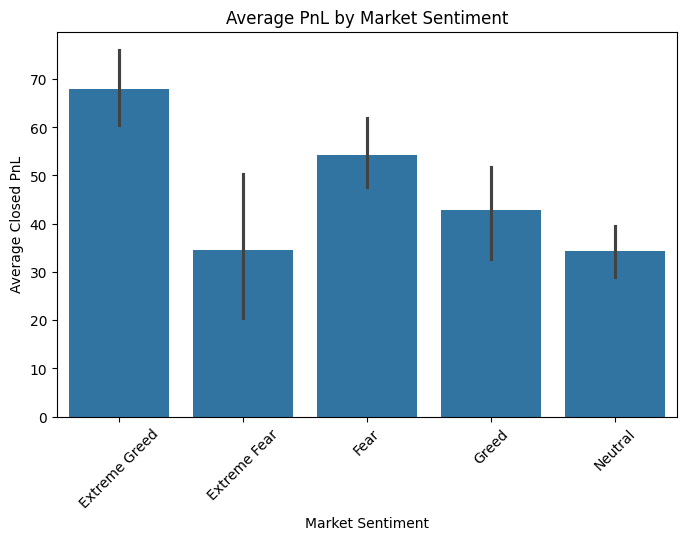

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged_df,
    x='classification',
    y='Closed PnL',
    estimator='mean'
)

plt.title('Average PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45)
plt.show()

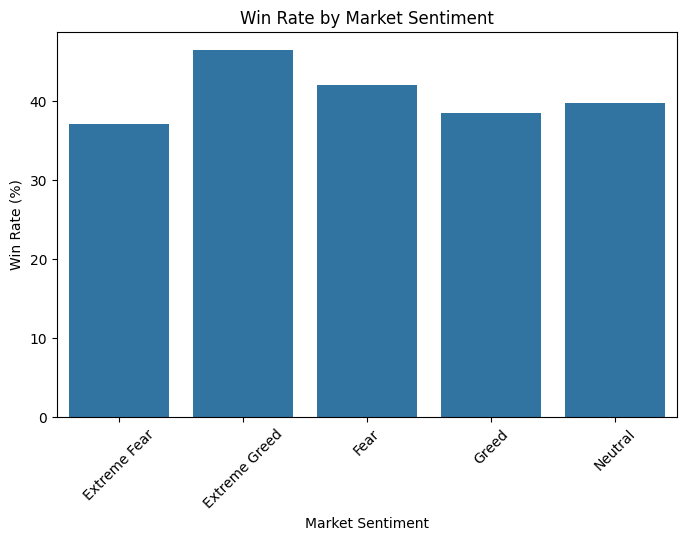

In [33]:
win_rate = merged_df.groupby('classification')['Win'].mean().reset_index()
win_rate['Win'] = win_rate['Win'] * 100

plt.figure(figsize=(8,5))

sns.barplot(
    data=win_rate,
    x='classification',
    y='Win'
)

plt.title('Win Rate by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=45)
plt.show()

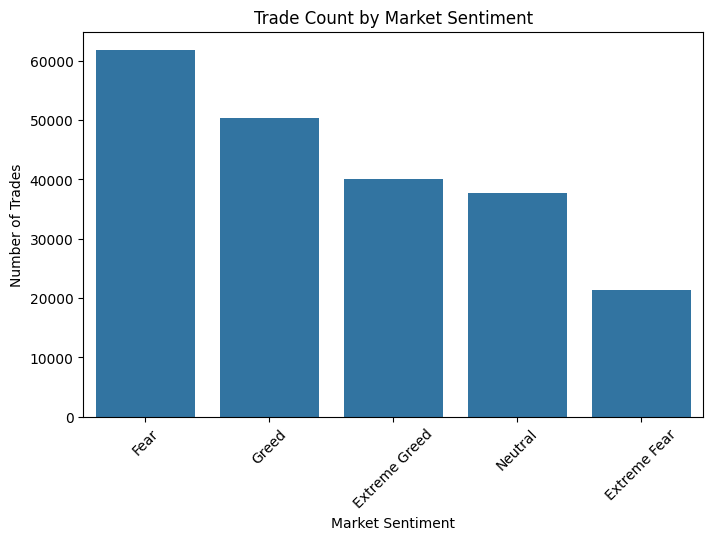

In [34]:
trade_count = merged_df['classification'].value_counts().reset_index()
trade_count.columns = ['classification', 'count']

plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_count,
    x='classification',
    y='count'
)

plt.title('Trade Count by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45)
plt.show()

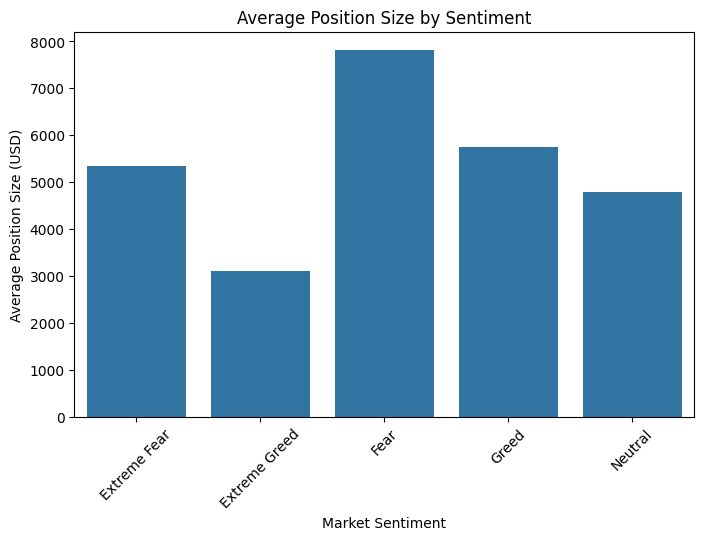

In [35]:
position_size = merged_df.groupby(
    'classification'
)['Size USD'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=position_size,
    x='classification',
    y='Size USD'
)

plt.title('Average Position Size by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Position Size (USD)')
plt.xticks(rotation=45)
plt.show()

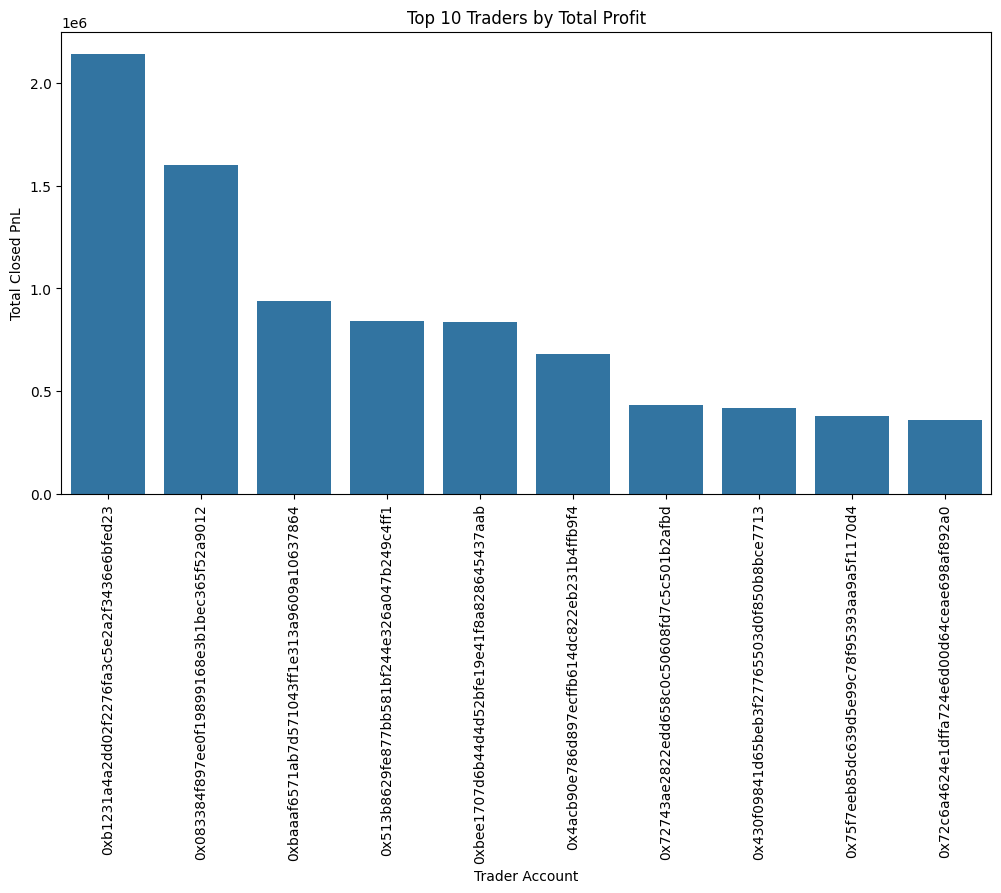

In [36]:
top10 = merged_df.groupby('Account')['Closed PnL'].sum() \
                 .sort_values(ascending=False) \
                 .head(10) \
                 .reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='Account',
    y='Closed PnL'
)

plt.title('Top 10 Traders by Total Profit')
plt.xlabel('Trader Account')
plt.ylabel('Total Closed PnL')
plt.xticks(rotation=90)
plt.show()

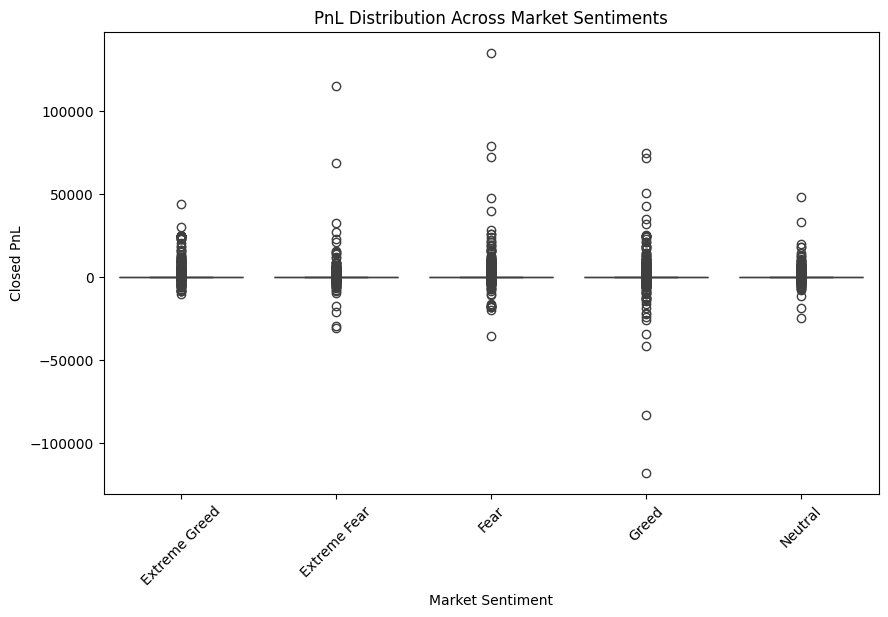

In [37]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged_df,
    x='classification',
    y='Closed PnL'
)

plt.title('PnL Distribution Across Market Sentiments')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL')
plt.xticks(rotation=45)

plt.show()

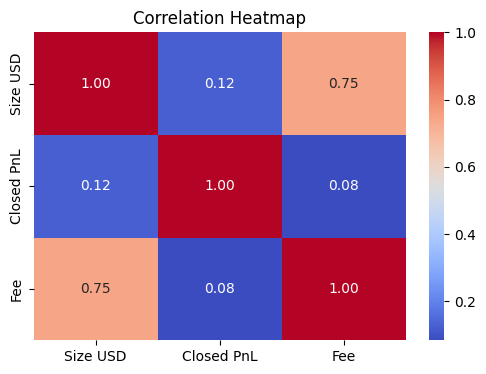

In [38]:
plt.figure(figsize=(6,4))

corr = merged_df[
    ['Size USD','Closed PnL','Fee']
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

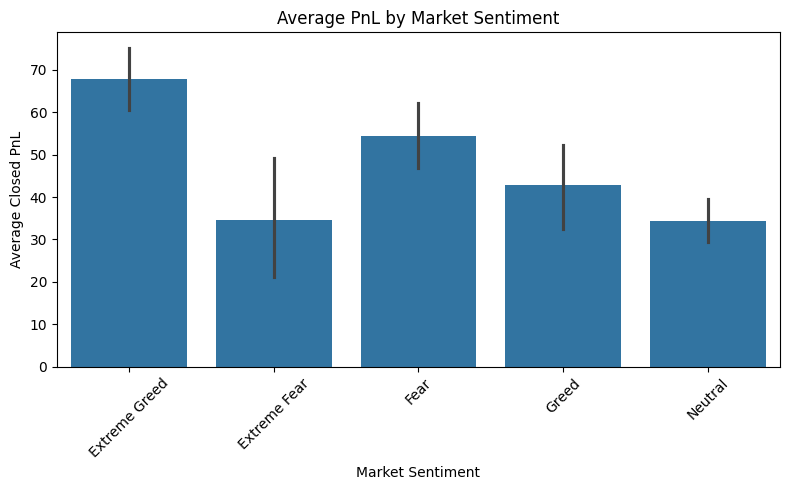

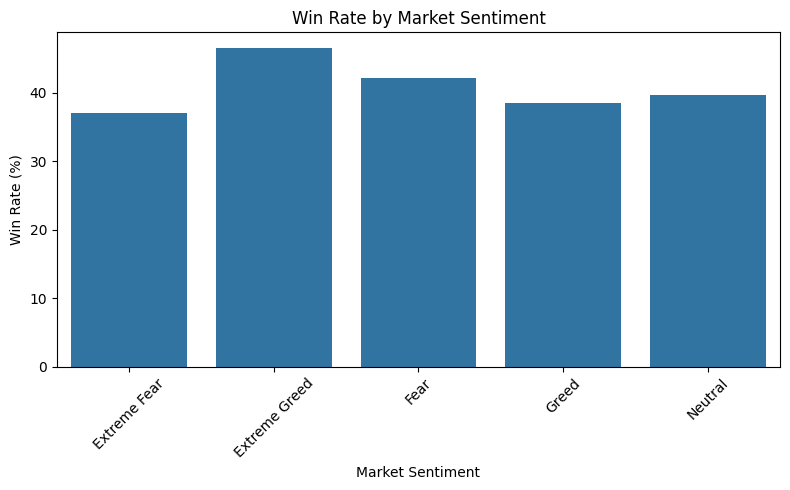

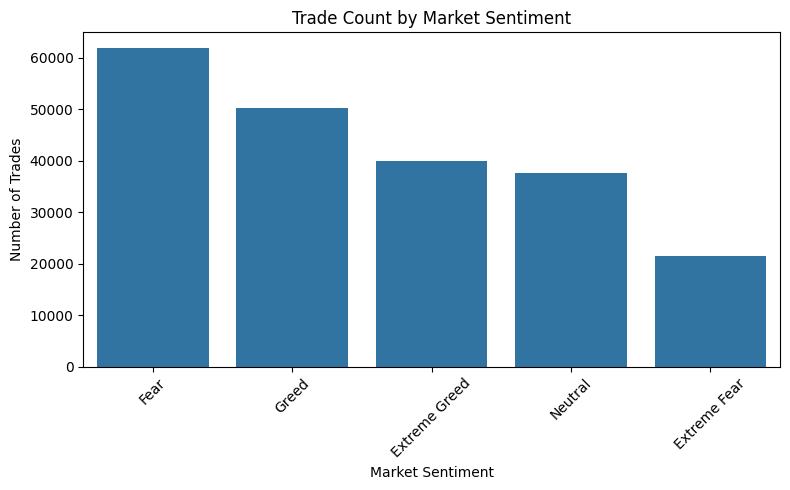

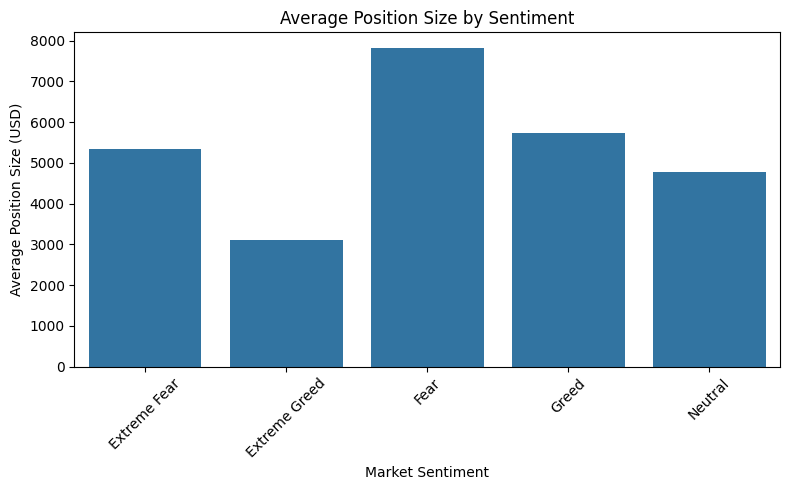

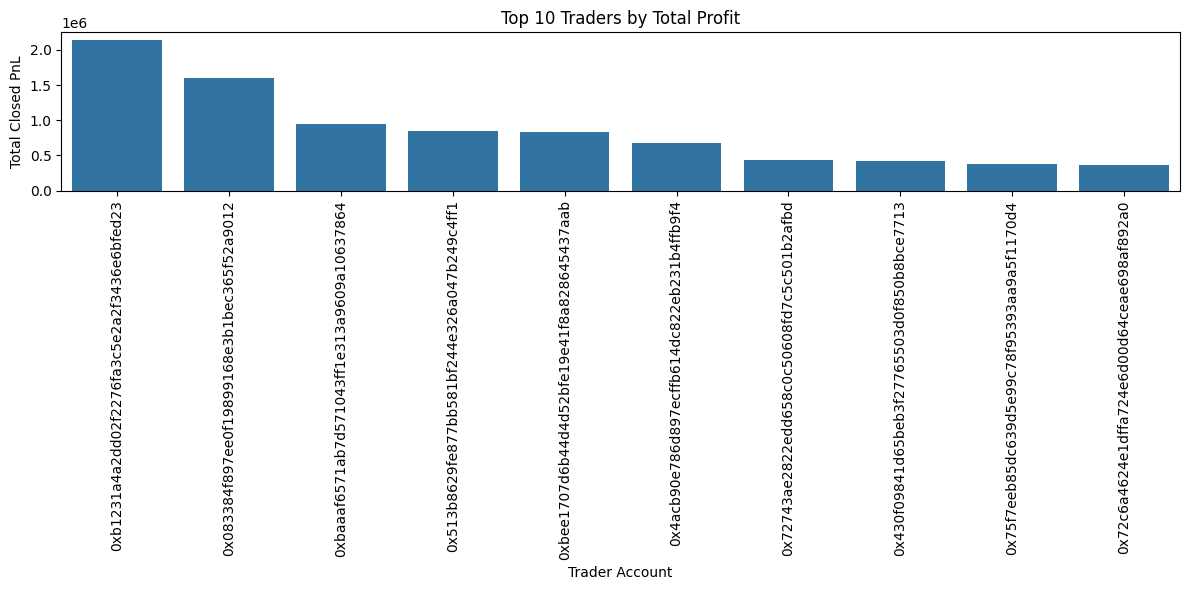

✅ All charts saved successfully!
📁 Location: ./visualizations/


In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create folder
os.makedirs("visualizations", exist_ok=True)

# -----------------------------
# 1. Average PnL by Sentiment
# -----------------------------
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged_df,
    x='classification',
    y='Closed PnL',
    estimator='mean'
)

plt.title('Average PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    'visualizations/avg_pnl_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# -----------------------------
# 2. Win Rate by Sentiment
# -----------------------------
win_rate = merged_df.groupby('classification')['Win'].mean().reset_index()
win_rate['Win'] = win_rate['Win'] * 100

plt.figure(figsize=(8,5))

sns.barplot(
    data=win_rate,
    x='classification',
    y='Win'
)

plt.title('Win Rate by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    'visualizations/win_rate_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# -----------------------------
# 3. Trade Count by Sentiment
# -----------------------------
trade_count = merged_df['classification'].value_counts().reset_index()
trade_count.columns = ['classification', 'count']

plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_count,
    x='classification',
    y='count'
)

plt.title('Trade Count by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    'visualizations/trade_count_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# -----------------------------
# 4. Position Size by Sentiment
# -----------------------------
position_size = merged_df.groupby(
    'classification'
)['Size USD'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=position_size,
    x='classification',
    y='Size USD'
)

plt.title('Average Position Size by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Position Size (USD)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    'visualizations/position_size_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# -----------------------------
# 5. Top 10 Traders
# -----------------------------
top10 = merged_df.groupby('Account')['Closed PnL'].sum() \
                 .sort_values(ascending=False) \
                 .head(10) \
                 .reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='Account',
    y='Closed PnL'
)

plt.title('Top 10 Traders by Total Profit')
plt.xlabel('Trader Account')
plt.ylabel('Total Closed PnL')
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    'visualizations/top_10_traders.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


print("✅ All charts saved successfully!")
print("📁 Location: ./visualizations/")